<a href="https://colab.research.google.com/github/jj-it-lab/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_7%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 오픈소스 기반 데이터 분석 7강 - 데이터 전처리 2

### 7-1 데이터 결측치 찾기

In [ ]:
import pandas as pd
import numpy as np

data = {'이름': ['김철수', '이영희', '박민수', '최지훈', '정소희'],
        '나이': [25, 30, np.nan, 22, 35],
        '도시': ['서울', None, '인천', '서울', '대전'],
        '점수': [90, 85, np.nan, 80, 92]}

df = pd.DataFrame(data)

## 결측치 여부 확인
print(df.isnull()) #결측치 존재시 True
print('----------------------------')
print(df.isna()) # isnull() 또는 isna() 동일한 기능
print('----------------------------')

## 열별, 행별 결측치 개수 확인
print(df.isnull().sum()) # 열 방향으로 True가 몇 개인지
print('----------------------------')
# 행 방향으로 True가 몇 개인지.
# 2차원에서 axis가 없거나(기본값) axis=0 이면 세로(열)방향, 1이면 가로(행)방향
print(df.isnull().sum(axis=1))
print('----------------------------')

## 특정 열, 행 결측치 확인
print(df[df.isnull().any(axis=1)]) # 결측치가 존재하는 특정 행을 찾음
print('----------------------------')
print(df[df['나이'].isnull()]) # 특정 열의 결측치를 확인
print('----------------------------')
print(df.columns[df.isnull().any()]) # 결측치가 하나라도 존재하는 특정 열을 찾음
print('----------------------------')

## 결측치가 아닌 항목 확인
print(df.notnull()) # 결측치가 아니면 True
print('----------------------------')

## 결측치 비율
print(df.isnull().sum().sum()/(df.shape[0]*df.shape[1]) * 100)
## 전체 데이터 개수 중에 null 값이 몇 개 있는가.
# 앞의 sum() : 컬럼별 합, 뒤의 sum() 각 결럼별 합의 합
# 전체 데이터 개수는 가로 * 세로


      이름     나이     도시     점수
0  False  False  False  False
1  False  False   True  False
2  False   True  False   True
3  False  False  False  False
4  False  False  False  False
----------------------------
      이름     나이     도시     점수
0  False  False  False  False
1  False  False   True  False
2  False   True  False   True
3  False  False  False  False
4  False  False  False  False
----------------------------
이름    0
나이    1
도시    1
점수    1
dtype: int64
----------------------------
0    0
1    1
2    2
3    0
4    0
dtype: int64
----------------------------
    이름    나이    도시    점수
1  이영희  30.0  None  85.0
2  박민수   NaN    인천   NaN
----------------------------
    이름  나이  도시  점수
2  박민수 NaN  인천 NaN
----------------------------
Index(['나이', '도시', '점수'], dtype='object')
----------------------------
     이름     나이     도시     점수
0  True   True   True   True
1  True   True  False   True
2  True  False   True  False
3  True   True   True   True
4  True   True   True   True
---------------

# 결측치 비율 구하기

1. df.shape의 구조
판다스(Pandas)의 shape은 데이터프레임의 크기(행과 열의 개수)를 튜플((행 개수, 열 개수)) 형태로 반환해 주는 속성(Attribute)입니다. 함수가 아니기 때문에 뒤에 괄호(())를 붙이지 않고 df.shape 형태로 사용합니다.

예를 들어 행이 5개, 열이 4개인 데이터프레임이라면 df.shape은 (5, 4) 라는 값을 돌려줍니다.

2. 파이썬의 튜플 인덱싱 ([0]과 [1])
파이썬에서 튜플이나 리스트는 0번부터 시작하는 인덱스 번호를 가집니다. 따라서 df.shape이 반환하는 값에서 원하는 항목을 콕 집어내기 위해 대괄호와 숫자를 사용합니다.

df.shape[0]: 튜플의 첫 번째 값인 행(Row, 세로 길이)의 개수를 가져옵니다. (위 예시에서는 5)

df.shape[1]: 튜플의 두 번째 값인 열(Column, 가로 길이)의 개수를 가져옵니다. (위 예시에서는 4)

3. 전체 데이터 개수 계산 (df.shape[0] * df.shape[1])
df.shape[0] (행 개수: 5) × df.shape[1] (열 개수: 4) = 20

즉, 데이터프레임 전체에 들어 있는 총 셀(Cell)의 개수가 20개라는 것을 의미합니다.

4. 전체 코드의 흐름 요약
작성하신 코드인 df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100은 다음과 같이 순서대로 동작합니다.

df.isnull().sum(): 각 열(Column)별 결측치 개수를 시리즈 형태로 구합니다. (예: [0, 1, 1, 1])

뒤쪽 .sum(): 열별 결측치 개수들을 전부 더해 데이터프레임 전체의 총 결측치 개수를 구합니다.

(df.shape[0] * df.shape[1]): 전체 데이터프레임의 총 셀 개수(행 × 열)를 구합니다.

(총 결측치 개수 / 총 셀 개수) * 100: 전체 데이터 중 결측치가 차지하는 비율(%)을 깔끔하게 계산해 냅니다.

### 7-2 데이터 시각화를 이용한 결측치 찾기

In [1]:
## matplotlib 사용시 한국어 사용을 위해
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

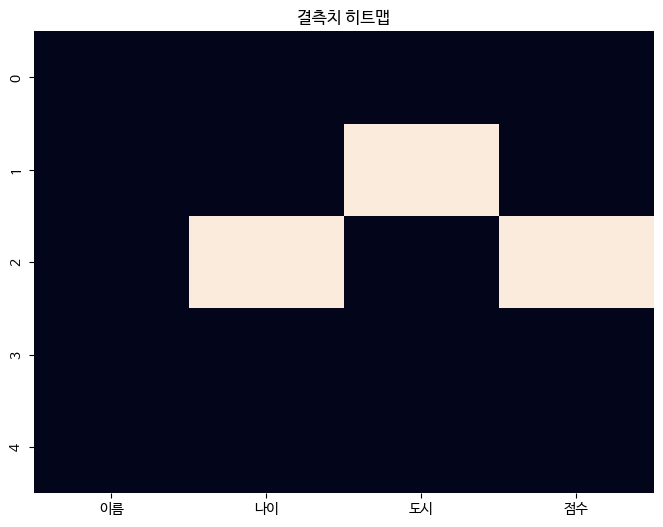

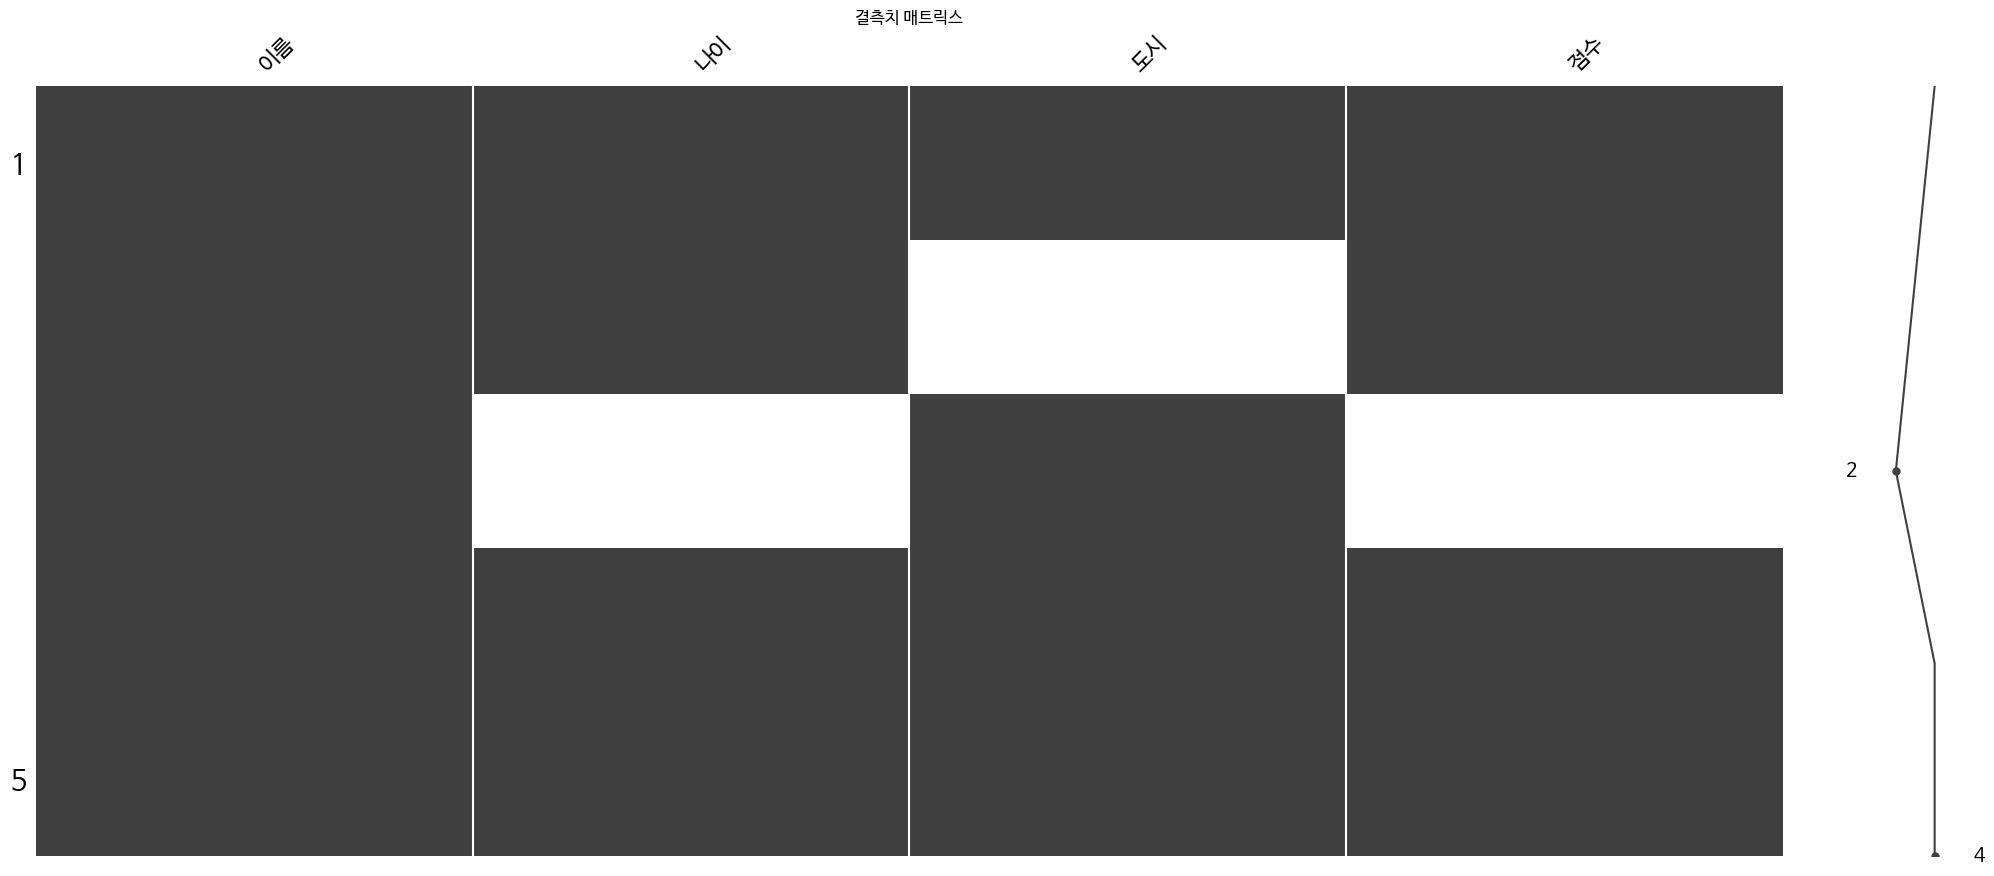

In [ ]:
import numpy as np
import pandas as pd

### 시각화 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

data = {'이름': ['김철수', '이영희', '박민수', '최지훈', '정소희'],
        '나이': [25, 30, np.nan, 22, 35],
        '도시': ['서울', None, '인천', '서울', '대전'],
        '점수': [90, 85, np.nan, 80, 92]}
df = pd.DataFrame(data)

### 결측치 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("결측치 히트맵")
plt.show()

### 결측치 매트릭스
msno.matrix(df)
plt.title("결측치 매트릭스")
plt.show()

### 7-3 사분위 범위를 통한 이상치 찾기

In [ ]:
import pandas as pd
import numpy as np

점수_데이터 = [72, 68, 75, 282, 64, 31, 78, 69, 88, 92, 22, 84, 61, -90, 130, 66]
학번_데이터 = list(range(1001, 1001 + len(점수_데이터)))

df = pd.DataFrame({
    '학번': 학번_데이터,
    '점수': 점수_데이터
})

### 사분위 범위 경계값 계산
q1 = df['점수'].quantile(0.25)
q3 = df['점수'].quantile(0.75)

iqr = q3 - q1

하한값 = q1 - 1.5 * iqr
상한값 = q3 + 1.5 * iqr

### IQR 통계량 출력
print(f'Q1 : {q1}')
print(f'Q3 : {q3}')
print(f'IQR : {iqr}')
print(f'하한값 : {하한값}')
print(f'상한값 : {상한값}')


Q1 : 63.25
Q3 : 85.0
IQR : 21.75
하한값 : 30.625
상한값 : 117.625


### 7-4 Z-점수를 통한 이상치 찾기

In [ ]:
import pandas as pd
import numpy as np

점수_데이터 = [72, 68, 75, 282, 64, 31, 78, 69, 88, 92, 22, 84, 61, -90, 130, 66]
학번_데이터 = list(range(1001, 1001 + len(점수_데이터)))

df = pd.DataFrame({
    '학번': 학번_데이터,
    '점수': 점수_데이터
})

### Z-점수 계산
점수_평균 =df['점수'].mean()
점수_표준편차 = df['점수'].std()
df['점수_z'] = (df['점수'] - 점수_평균)/ 점수_표준편차
print(df)
print('----------------------------')

### 임계값 설정 및 이상치 여부 판단
임계값 = 2
df['이상치여부'] = df['점수_z'].abs() > 임계값
print(df)
print('----------------------------')

### 이상치 데이터 출력
print(df[df['이상치여부']])
print('----------------------------')

### 이상치 비율 출력
print(df['이상치여부'].mean() * 100) # Boolean 이어서 그대로 평균 내면 됨

      학번   점수      점수_z
0   1001   72 -0.034475
1   1002   68 -0.089635
2   1003   75  0.006895
3   1004  282  2.861411
4   1005   64 -0.144794
5   1006   31 -0.599862
6   1007   78  0.048265
7   1008   69 -0.075845
8   1009   88  0.186164
9   1010   92  0.241324
10  1011   22 -0.723972
11  1012   84  0.131004
12  1013   61 -0.186164
13  1014  -90 -2.268444
14  1015  130  0.765341
15  1016   66 -0.117214
----------------------------
      학번   점수      점수_z  이상치여부
0   1001   72 -0.034475  False
1   1002   68 -0.089635  False
2   1003   75  0.006895  False
3   1004  282  2.861411   True
4   1005   64 -0.144794  False
5   1006   31 -0.599862  False
6   1007   78  0.048265  False
7   1008   69 -0.075845  False
8   1009   88  0.186164  False
9   1010   92  0.241324  False
10  1011   22 -0.723972  False
11  1012   84  0.131004  False
12  1013   61 -0.186164  False
13  1014  -90 -2.268444   True
14  1015  130  0.765341  False
15  1016   66 -0.117214  False
----------------------------
      학

### 7-5 평균값 및 선형보간법을 통한 결측치 처리

In [ ]:
import pandas as pd
import numpy as np

file_path = "raw_large_shopping_customer.csv"
df = pd.read_csv(file_path)
print(df.isnull().sum())

df_cleaned = df.dropna(thresh=df.shape[1] - 1)

### 나이, 소득 평균값 대치 및 결과 출력


### 지출, 평균구매횟수 선형보간법 적용


df_cleaned.to_csv("cleaned_large_shopping_customer.csv", index=False, encoding="utf-8-sig")

### 7-6 DataFrame 값 변경

In [ ]:
import pandas as pd

data = {'age': [25, 30, None, 22, 35],
        'city': ['Seoul', None, 'Incheon', 'Seoul', 'Daejeon'],
        'score': [90, 85, None, 80, 92]}
df = pd.DataFrame(data)

### replace를 이용한 Seoul -> 서울

### replace를 이용한 None -> 미정, Incheon -> 인천

### map을 이용한 값 변경
city_map = {'Seoul': '서울특별시', None: '미정', 'Incheon':'인천광역시', 'Daejeon':'대전광역시'}

### apply 함수를 이용한 값 변경

### apply 함수를 이용한 행단위 값 변경

### loc 인덱스를 이용한 값 변경

### where 함수를 이용한 값 변경



### 7-7 날짜 데이터 타입 다루기


In [ ]:
date_str = ['2025-07-01', '2025-08-01', '2025-09-01']
df_date = pd.DataFrame({'date_str':date_str})

### datetime 타입 변환

### 날짜 데이터 분리

### 날짜 데이터 포멧 변경


## 7-8 실습 시나리오 - 데이터 정제

### [재수행] 6-5 실습 시나리오 - Kaggle을 활용한 데이터 수집 및 측정

### 데이터 분포 시각화

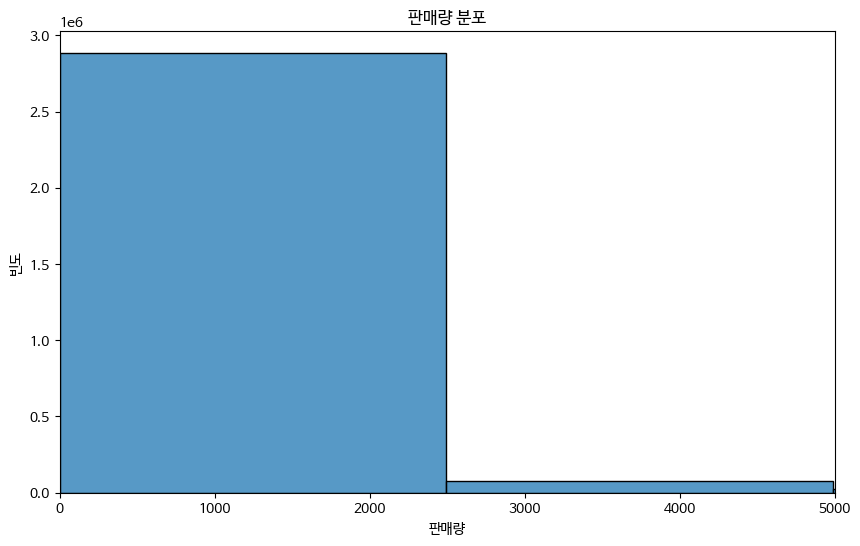

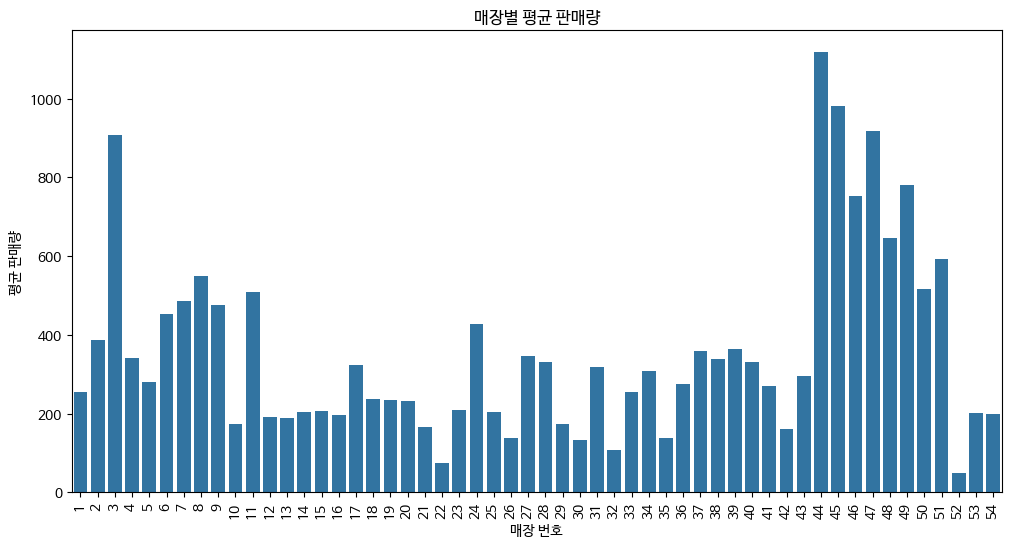

In [3]:
import numpy as np
import pandas as pd

### 시각화 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Grocery Sales 데이터 DataFrame 로드
train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
transactions = pd.read_csv('transactions.csv')
oil = pd.read_csv('oil.csv')
holidays_events = pd.read_csv('holidays_events.csv')

plt.figure(figsize=(10, 6))
sns.histplot(train['sales'], bins=50)
plt.title("판매량 분포")
plt.xlabel("판매량")
plt.ylabel("빈도")
plt.xlim(0, 5000)
plt.show()

store_sales = train.groupby('store_nbr')['sales'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='store_nbr', y='sales', data=store_sales)
plt.title("매장별 평균 판매량")
plt.xlabel("매장 번호")
plt.ylabel("평균 판매량")
plt.xticks(rotation=90)
plt.show()

### 결측치 처리

In [9]:
## 판매, 매장, 거래, 원유, 휴일이벤트 데이터 결측치
print(train.isnull().sum())
print('---------------------------')
print(stores.isnull().sum())
print('---------------------------')
print(transactions.isnull().sum())
print('---------------------------')
print(oil.isnull().sum())
print('---------------------------')
print(holidays_events.isnull().sum())

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
---------------------------
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64
---------------------------
date            0
store_nbr       0
transactions    0
dtype: int64
---------------------------
date           0
dcoilwtico    43
dtype: int64
---------------------------
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


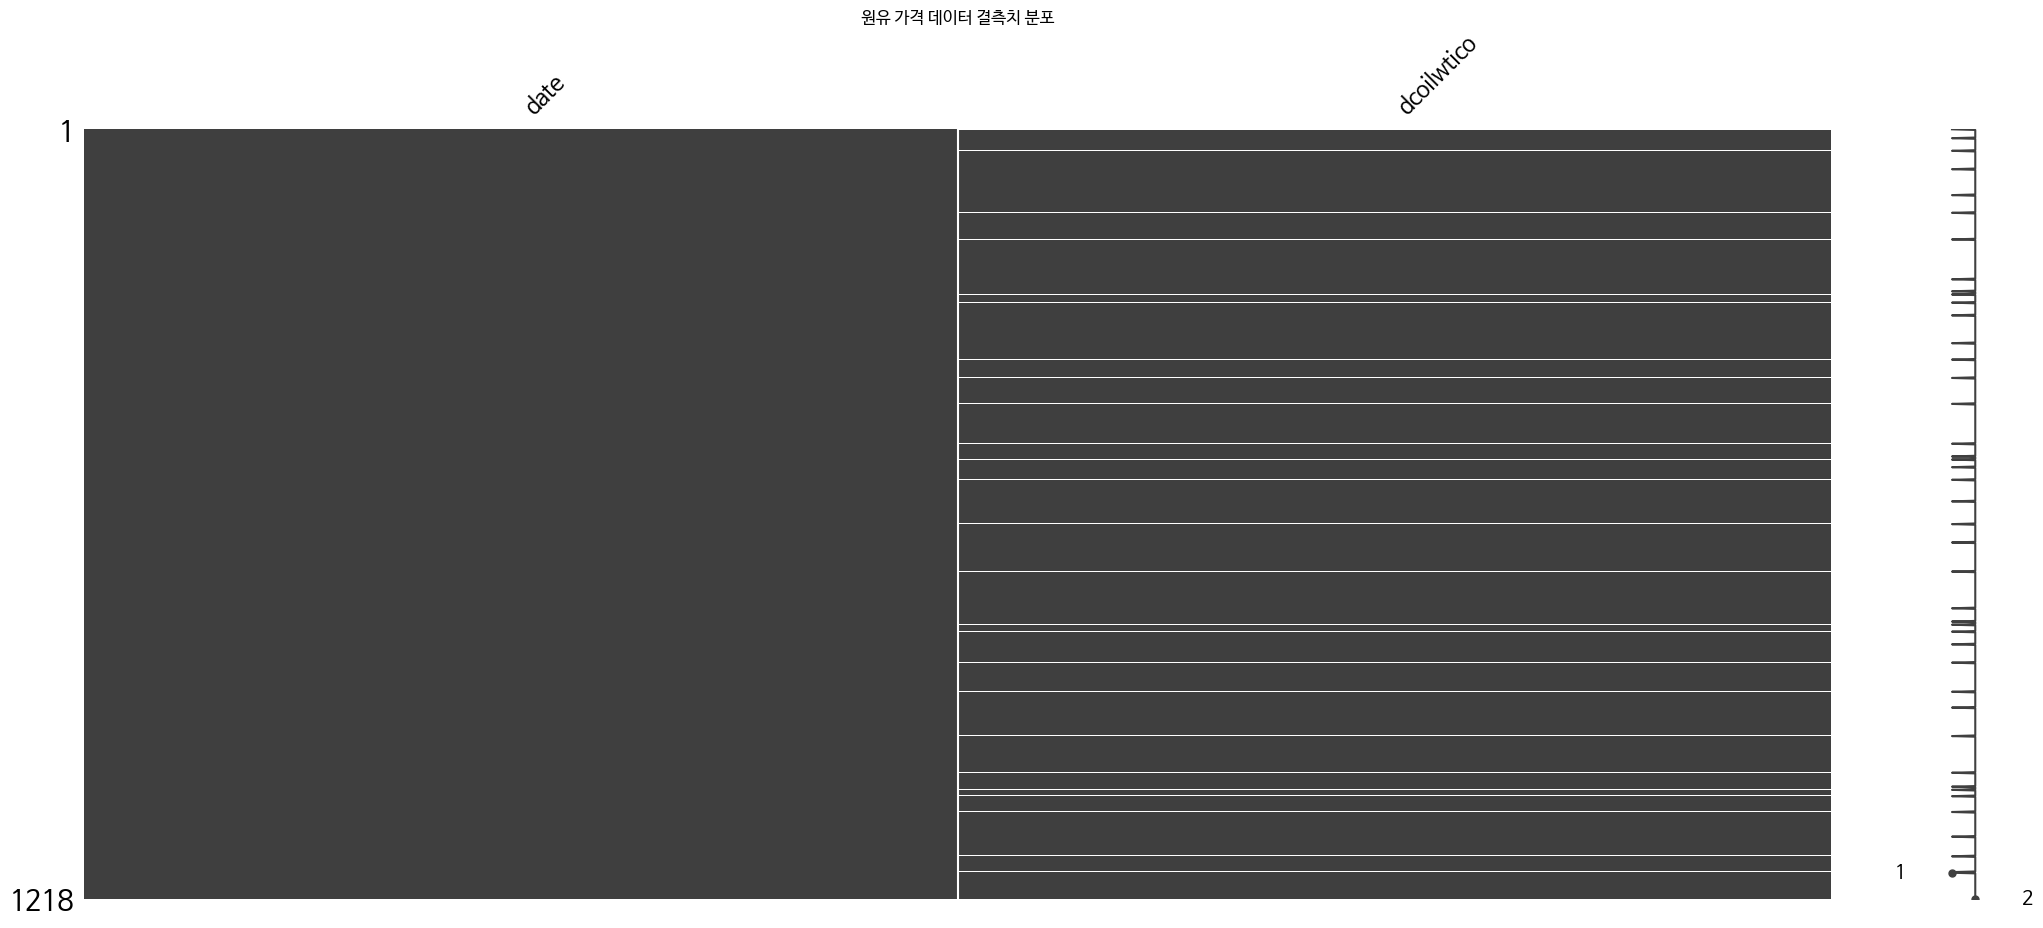

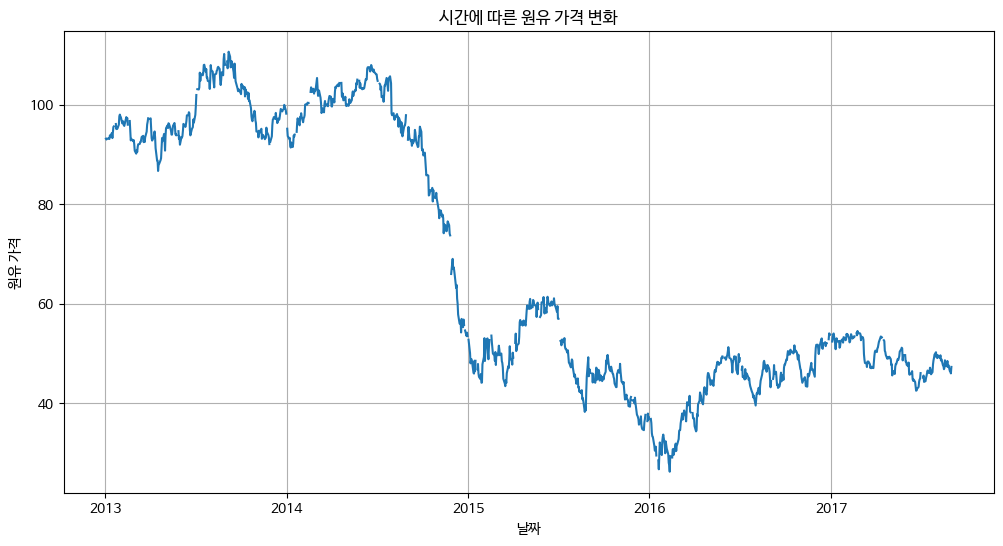

In [10]:
import missingno as msno

msno.matrix(oil)
plt.title("원유 가격 데이터 결측치 분포")
plt.show()

oil['date'] = pd.to_datetime(oil['date'])
plt.figure(figsize=(12, 6))
plt.plot(oil['date'], oil['dcoilwtico'])
plt.title("시간에 따른 원유 가격 변화")
plt.xlabel("날짜")
plt.ylabel("원유 가격")
plt.grid(True)
plt.show()

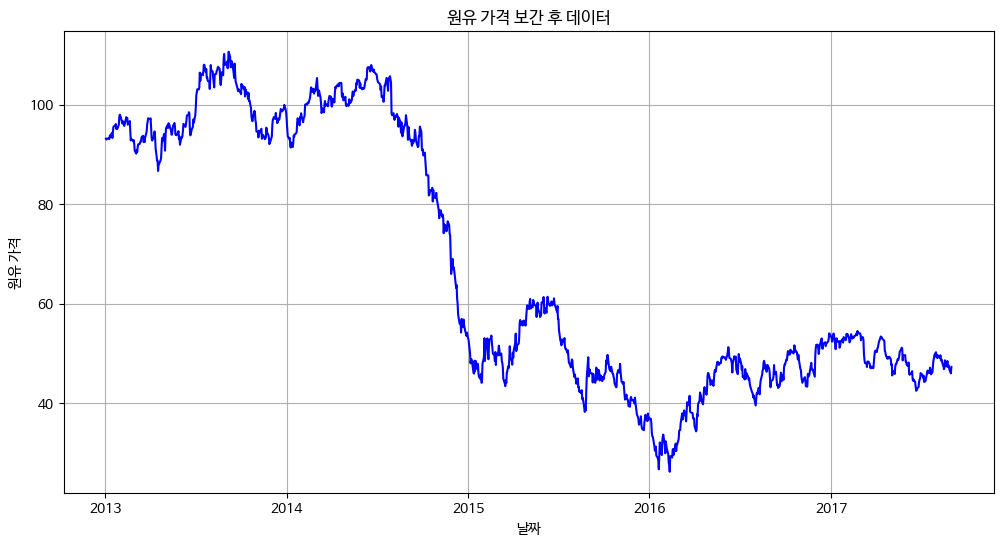

In [11]:
oil_cleaned = oil.copy()

### 선형 보간법 적용한 원유 가격 데이터
oil_cleaned['dcoilwtico'] = oil_cleaned['dcoilwtico'].interpolate(method = 'linear')


plt.figure(figsize=(12, 6))
plt.plot(oil_cleaned['date'], oil_cleaned['dcoilwtico'], 'b-')
plt.title("원유 가격 보간 후 데이터")
plt.xlabel("날짜")
plt.ylabel("원유 가격")
plt.grid(True)
plt.show()

### 이상치 처리

이상치 개수: 200,274건
전체 대비 비율: 6.67%


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


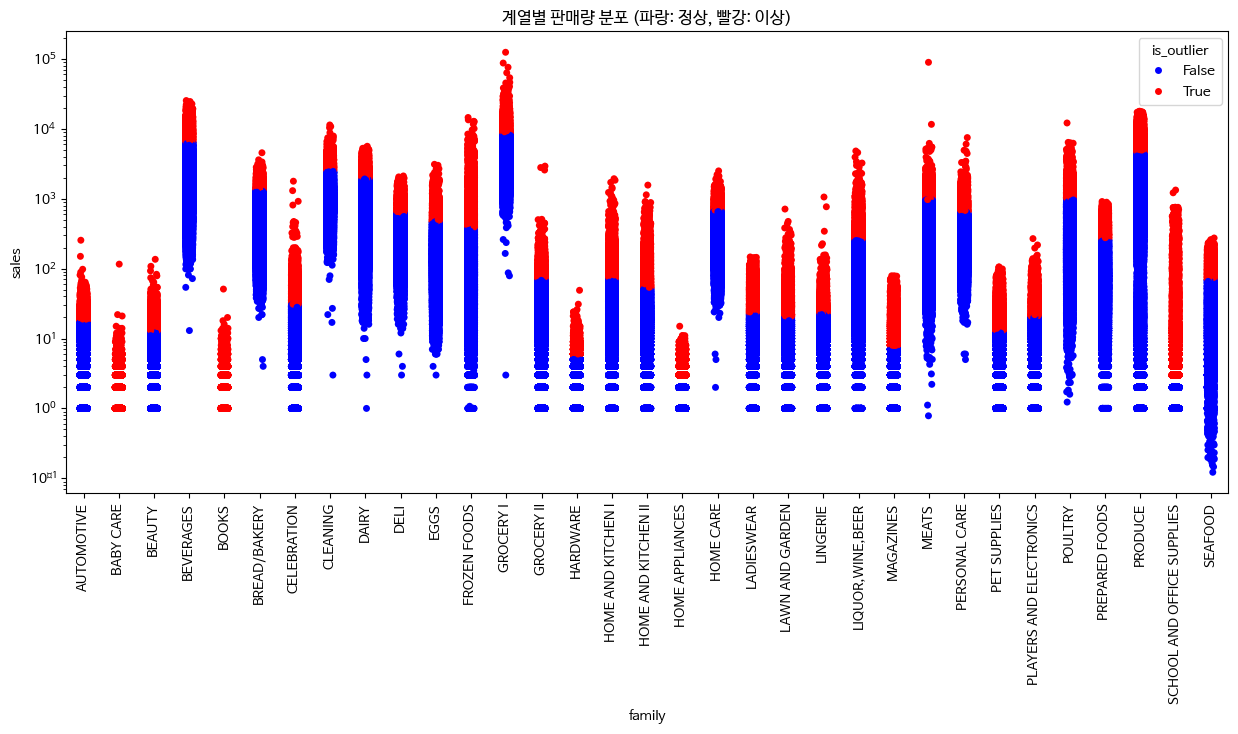

In [14]:
### 제품 계열별 판매 데이터 IQR 계산
family_bounds = train.groupby('family')['sales'].apply(
    lambda x : x.quantile(0.75) + 1.5 * (x.quantile(0.75)-x.quantile(0.25))
)

### 상한값 초과 판매량 이상치 분류
train_enhanced = train.copy()
train_enhanced['upper_bound'] = train_enhanced['family'].map(family_bounds)
train_enhanced['is_outlier'] = train_enhanced['sales'] > train_enhanced['upper_bound']

total_outliers = train_enhanced['is_outlier'].sum()
total_ratio = train_enhanced['is_outlier'].mean()

print(f"이상치 개수: {total_outliers:,}건")
print(f"전체 대비 비율: {total_ratio:.2%}")

plt.figure(figsize=(15,6))
sns.stripplot(x='family', y='sales', hue=train_enhanced['is_outlier'],
              data=train_enhanced, palette={False:'blue', True:'red'})
plt.xticks(rotation=90)
plt.yscale('log')
plt.title('계열별 판매량 분포 (파랑: 정상, 빨강: 이상)')
plt.show()

In [ ]:
upper_bounds = family_bounds['upper_bound']

### 판매량이 상한값 초과 시, 판매량으로 상한값으로 대체
train_cleaned  = train.copy()


changed_count = (train['sales'] != train_cleaned ['sales']).sum()
print(f"대체된 데이터 수: {changed_count}건")

### 날짜 데이터 처리

In [ ]:
### 판매, 거래, 휴일 이벤트, 원율 데이터 내 date 컬럼 데이터 datetime 데이터 타입으로 변경



train_cleaned['year'] = train_cleaned['date'].dt.year
train_cleaned['month'] = train_cleaned['date'].dt.month
train_cleaned['day'] = train_cleaned['date'].dt.day
train_cleaned['dayofweek'] = train_cleaned['date'].dt.dayofweek
### 주말, 월초, 월말 여부 추철


print("날짜 특성 추출 결과:")
print(train_cleaned[['date', 'year', 'month', 'day', 'dayofweek', 'weekend', 'is_month_start', 'is_month_end']].head())

In [ ]:
## 요일별 평균 판매량을 계산

## 요일 출력값 변경

plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='sales', data=day_sales)
plt.title("요일별 평균 판매량")
plt.xlabel("요일")
plt.ylabel("평균 판매량")
plt.show()

### 데이터 통합

In [ ]:
## 판매, 거래 데이터 통합


## 매장 데이터 통합


## 원유 데이터 통합


print("최종 데이터셋 정보:")
print(f"행 개수: {train_final.shape[0]}, 열 개수: {train_final.shape[1]}")
print(train_final.columns.tolist())
print(train_final.head())